In [1]:
#Import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from statistics import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.backends.backend_pdf import PdfPages
import math
from scipy import stats
import sys
import copy
from collections import Counter
from collections import defaultdict
from datetime import datetime
from sklearn.ensemble import IsolationForest

In [3]:
patients=[1135, 1497, 1504, 1450, 1660, 
          1615, 1559, 1582, 1586,1617,
          1511, 1541,1607, 1603, 1609, 
          1628, 1657, 1464, 1572, 1706]

In [4]:
threshold=30*60

In [5]:
def readData(patient):
    tm = pd.read_csv(f"{patient}_cleaned_removedays"'.csv')
    out = np.array(tm).tolist()  

    return out

In [6]:
def read_left(patient):
    threshold=1800
    try:
        #file.csv is an empty csv file
        tm = pd.read_csv(f"{patient,threshold}_left_days_outing_living"'.csv')
        # Convert 'Date' to datetime format
        tm['Date'] = pd.to_datetime(tm['Date'])
        tm['Date'] =tm['Date'].dt.strftime('%d/%m/%Y')
        left_days_hours = np.array(tm).tolist() 
    
    except pd.errors.EmptyDataError:
        left_days_hours =[]
    return left_days_hours

In [7]:
def readdate(out): #read all date
    new_date=[]
    for i in range(len(out)):
        dt = out[i][0].split(' ')[0]
        if dt not in new_date:
            new_date.append(dt)
    return new_date

In [8]:
# patients_to_remove=[]
# for patient in patients:
#     out=readData(patient)
#     new_date=readdate(out)
#     new_dates = [datetime.strptime(date, '%d/%m/%Y') for date in new_date]

#     # Sort dates just in case they are not in order
#     new_dates.sort()

#     # Check the year of the first and last date
#     if new_dates[0].year == new_dates[-1].year:
#         print(patient)
#         # If the year is the same, add patient to the list for removal
# #         patients_to_remove.append(patient)

In [9]:
def rearrange_sensor_data(data):
    from datetime import datetime
    # Convert the date-time strings to datetime objects for correct sorting
    for record in data:
        record[0] = datetime.strptime(record[0], '%d/%m/%Y %H:%M:%S')
    # Sorting the data by datetime
    sorted_data = sorted(data, key=lambda x: x[0])
    # Rearranging the inactive events


    # Convert datetime objects back to strings
    for record in sorted_data:
        record[0] = record[0].strftime('%d/%m/%Y %H:%M:%S')
    return sorted_data

## Outing

In [10]:
def total_outing(left):
    days = []
    for each in left:
        day=datetime.strptime(each[0], '%d/%m/%Y').date()
        if day not in days:
            days.append(day)
    return days

In [12]:
from datetime import datetime

def total_outing_improved(left):
    outings_by_day = {}

    # Use a temporary set to store unique identifiers (date and time range)
    seen = set()
    unique_left = []

    for item in left:
        identifier = (item[0], tuple(item[1]))  # Create a hashable identifier from the date and time range

        if identifier not in seen:
            unique_left.append(item)  # unique_left now contains entries without duplicates based on the first two items
            seen.add(identifier)


    
    for entry in unique_left:
        day_str, _, hour, left_time, _ = entry
        day = datetime.strptime(day_str, '%d/%m/%Y').date()
        
        # Ensure the day key exists in the dictionary
        if day not in outings_by_day:
            outings_by_day[day] = []
            
        # Add the hour to the set for that day
        outings_by_day[day].append(left_time)
    
#     # sum all left seconds and convert to hours
    outings_count = {day: round(sum(left_times)/3600,2) for day, left_times in outings_by_day.items()}
    
    return outings_count



In [13]:
from datetime import datetime, date

def count_days_and_hours_in_ranges(date_ranges, outing_counts):
    results = []
    for start_date, end_date in date_ranges:
        # Make sure start_date and end_date are datetime.date objects
        if isinstance(start_date, datetime):
            start_date = start_date.date()
        if isinstance(end_date, datetime):
            end_date = end_date.date()

        # Initialize count of days and hours
        days_count = 0
        hours_count = 0
        for day, hours in outing_counts.items():
            # Ensure 'day' is a datetime.date object for comparison
            if isinstance(day, datetime):
                day = day.date()

            if start_date <= day <= end_date:
                days_count += 1
                hours_count += hours
        results.append((start_date, end_date, days_count, hours_count))
    return results


In [14]:
# Function to count outing days within each date range
def count_days_in_ranges(date_ranges, outing_days):
    counts = []
    for start_date, end_date in date_ranges:
        # Count how many outing days fall within the current date range
        count = sum(1 for day in outing_days.keys() if start_date <= day <= end_date)
        counts.append((start_date, end_date, count))
    return counts


In [15]:
# Function to check for missing dates within each chunk
def find_missing_dates(date_ranges, cleaned_data_all):
    # Convert cleaned_data dates to datetime.date objects
    cleaned_dates = [datetime.strptime(entry[0], '%d/%m/%Y %H:%M:%S').date() for entry in cleaned_data_all]

    missing_dates_by_range = []
    for start_date, end_date in date_ranges:
        expected_dates = {start_date + timedelta(days=x) for x in range((end_date - start_date).days + 1)}
        missing_dates = expected_dates - set(cleaned_dates)
        missing_dates_by_range.append((start_date, end_date, sorted(list(missing_dates))))
    return missing_dates_by_range



In [16]:
from datetime import datetime, timedelta

def generate_monthly_date_ranges(start_date, total_segments=None):
    current_start_date = start_date
    segments_generated = 0
    
    while total_segments is None or segments_generated < total_segments:
        # Calculate the last day of the current month
        next_month = current_start_date.month % 12 + 1
        next_month_year = current_start_date.year + (current_start_date.month // 12)
        # Set day to the first of the next month, then subtract one day to get the end of the current month
        current_end_date = (datetime(next_month_year, next_month, 1) - timedelta(days=1)).date()
        
        yield (current_start_date, current_end_date)
        
        # Update the start date to the first of the next month
        current_start_date = current_end_date + timedelta(days=1)
        segments_generated += 1


### Number of data we have for each patient

In [17]:
def generate_dates_for_months(year_month_list):
    dates = []
    for year, month in year_month_list:
        start_date = datetime.date(year, month, 1)
        _, days_in_month = calendar.monthrange(year, month)
        for day in range(days_in_month):
            dates.append(start_date + datetime.timedelta(days=day))
    return dates

In [18]:
import calendar

outing_results={}
outing_hrs={}

# 
import random
from collections import defaultdict
final_result={}

final_result_hours={}
threshold_levels = [0.1, 0.2, 0.3,0.4, 0.5, 0.6, 0.7, 0.8, 0.9]



complete_month={}
for num in patients:
    patient = num
    outing_results[num]={}
    outing_hrs[num]={}
    #read data

    print('patient',num)
    out = readData(patient)
    from datetime import datetime
    left=read_left(patient)
#     visitor=readData_visitor(patient)
   
    final_result[num]=[]
    final_result_hours[num]=[]
    #<1> processing data
    #all
    cleaned_data_all=rearrange_sensor_data(out)#rearrange_sensor_data(filter_data(out,visitor,left))
#     print(len(cleaned_data_all))


    #<2> count outing
    #find all outing days
    outing_days=total_outing_improved(left)


#     days=count_outing(cleaned_data_all)
 
    # Convert dates to datetime.date objects for easy manipulation-----------use the first 6 months
    dates=readdate(out) [:180]
    from datetime import datetime, timedelta
    start_date = datetime.strptime(dates[0], '%d/%m/%Y').date()
    end_date = datetime.strptime(dates[-1], '%d/%m/%Y').date()
    
    
    # date_ranges
    total_days = (end_date - start_date).days + 1
    total_segments = (total_days + 29) // 30  
#     date_ranges = list(generate_date_ranges(start_date, total_segments=total_segments))
    date_ranges = list(generate_monthly_date_ranges(start_date, total_segments=total_segments))
    # Count the days in outing_days for each date range
    counts_in_ranges = count_days_and_hours_in_ranges(date_ranges, outing_days)
    
    
    # Find missing dates within each date range
    missing_dates_by_range = find_missing_dates(date_ranges, cleaned_data_all)
    
    complete_month[num]={}
    for start_date, end_date, count,total_hour in counts_in_ranges:
        
        print(f"From {start_date} to {end_date}, number of outing days: {count}","total_hour",round(total_hour,2))
        for start_date_missing, end_date_missing, missing_dates in missing_dates_by_range:
            if start_date_missing==start_date and start_date.day == 1:
#                 complete_month[num][start_date]=[]
                
                _, num_days_in_month = calendar.monthrange(start_date.year, start_date.month)
                print(f"From {start_date} to {end_date}, missing dates: {len(missing_dates)}",'num_days_in_month',num_days_in_month)
                if len(missing_dates)==0 and count>0:
                    complete_month[num][start_date]=[count,total_hour]
    
    results = defaultdict(lambda: defaultdict(list))
    results_hours = defaultdict(lambda: defaultdict(list)) 
    
    for threshold in threshold_levels:
        for _ in range(100):  # Repeat 10 times for robustness                
                
        # Step 1: Aggregate outings by month for the selected dataset
            import datetime
            
            # Randomly select 2 months from the complete_month dictionary
            # selected_months_all = random.sample(list(complete_month.items()), 2)
            selected_months_all = random.sample(list(complete_month[num].items()), 1)


            # Aggregate outing days by month to facilitate the analysis
            total_actual_outings =  sum(details[1][0] for details in selected_months_all)
            total_hours = sum(details[1][1] for details in selected_months_all)

            print(num,selected_months_all,'total_actual_outings', total_actual_outings,'total_hours',total_hours)


            # selected_months=[(selected_months_all[0][0].year, selected_months_all[0][0].month),
            #                  (selected_months_all[1][0].year, selected_months_all[1][0].month)]

            # Generate a set of (year, month) tuples from selected_months_all
            selected_year_month = {(date.year, date.month) for date, data in selected_months_all}

            # Filter outing_days to only include days where (year, month) is in selected_year_month
            filtered_outing_days = {date: outings for date, outings in outing_days.items() if (date.year, date.month) in selected_year_month}

#             # filtered_outing_days

            # Correct dictionary comprehension to extract year and month from date objects
            num_days_in_month_corrected = {date.month: calendar.monthrange(date.year, date.month)[1] for date, data in selected_months_all}
#             num_days_in_month_corrected = {month: calendar.monthrange(year, month)[1] for year, month in selected_months_all}
            total_days_in_selected_months = sum(num_days_in_month_corrected.values())
            print('total_days_in_selected_months', total_days_in_selected_months)



        # Step 2-5: Simulate the process for each threshold
            #Randomly select days based on threshold
            days_to_remove = math.floor(total_days_in_selected_months * threshold)
#             print('Threshold',threshold,'Days to Remove',days_to_remove)

            # Generate the list of dates
            all_dates = generate_dates_for_months(selected_year_month)
            remaining_days = random.sample(all_dates, len(all_dates) - days_to_remove)
        # (1) outings
            # Calculate total count based on existence in filtered_outing_days
            total_count = sum(1 for day in remaining_days if day in filtered_outing_days)
            print('all_dates',len(all_dates),'remaining_days',len(remaining_days))
            
            # Calculate prorated total outings
            prorated_total = math.floor((total_count * len(all_dates))/ len(remaining_days))
         
            
            
            error = abs(prorated_total - total_actual_outings)
            if total_actual_outings!=0:# avoid division by zero
                print('prorated_total',prorated_total,'total_actual_outings',total_actual_outings)
                relative_errors = (abs(prorated_total - total_actual_outings)/total_actual_outings)
                results[threshold]['relative_errors'].append(relative_errors)
                results[threshold]['prorated_outings'].append(prorated_total)
                results[threshold]['errors'].append(error)
                results_hours[threshold]['actual_hour'].append(total_actual_outings)
            final_result[num]=results
            
            
        # (2) outings_hours    
        # Calculate total outing hours based on remaining_days in filtered_outing_days
            
            total_remaining_hours = sum(filtered_outing_days[day] for day in remaining_days if day in filtered_outing_days)

            # Prorate total hours to estimate total monthly outing hours
            prorated_total_hours = (total_remaining_hours *  len(all_dates) ) / len(remaining_days)

            #actual_total_outing_hours = total_hours
            
            # Calculate relative error for hours (if actual_total_outing_hours is not zero)
            if total_hours != 0:  # avoid division by zero
                # Calculate error for hours
                error_hours = abs(prorated_total_hours - total_hours)
                relative_error_hours = error_hours / total_hours
                print('prorated_total_hours',prorated_total_hours,'total_hours',total_hours,
                      'error_hours',error_hours,'relative_error_hours',relative_error_hours)
                
                
                # Store the results
                results_hours[threshold]['relative_errors'].append(relative_error_hours)
                results_hours[threshold]['prorated_outings'].append(prorated_total_hours)
                results_hours[threshold]['errors'].append(error_hours)
                results_hours[threshold]['actual_hour'].append(total_hours)
            final_result_hours[num]=results_hours
            


patient 1135
From 2018-06-13 to 2018-06-30, number of outing days: 7 total_hour 16.38
From 2018-07-01 to 2018-07-31, number of outing days: 17 total_hour 25.57
From 2018-07-01 to 2018-07-31, missing dates: 0 num_days_in_month 31
From 2018-08-01 to 2018-08-31, number of outing days: 16 total_hour 20.75
From 2018-08-01 to 2018-08-31, missing dates: 0 num_days_in_month 31
From 2018-09-01 to 2018-09-30, number of outing days: 16 total_hour 15.45
From 2018-09-01 to 2018-09-30, missing dates: 0 num_days_in_month 30
From 2018-10-01 to 2018-10-31, number of outing days: 19 total_hour 18.58
From 2018-10-01 to 2018-10-31, missing dates: 0 num_days_in_month 31
From 2018-11-01 to 2018-11-30, number of outing days: 11 total_hour 14.21
From 2018-11-01 to 2018-11-30, missing dates: 0 num_days_in_month 30
From 2018-12-01 to 2018-12-31, number of outing days: 18 total_hour 20.47
From 2018-12-01 to 2018-12-31, missing dates: 0 num_days_in_month 31
1135 [(datetime.date(2018, 10, 1), [19, 18.58])] total_a

1135 [(datetime.date(2018, 9, 1), [16, 15.45])] total_actual_outings 16 total_hours 15.45
total_days_in_selected_months 30
all_dates 30 remaining_days 27
prorated_total 15 total_actual_outings 16
prorated_total_hours 15.366666666666667 total_hours 15.45 error_hours 0.08333333333333215 relative_error_hours 0.005393743257820851
1135 [(datetime.date(2018, 12, 1), [18, 20.470000000000002])] total_actual_outings 18 total_hours 20.470000000000002
total_days_in_selected_months 31
all_dates 31 remaining_days 28
prorated_total 16 total_actual_outings 18
prorated_total_hours 18.500357142857137 total_hours 20.470000000000002 error_hours 1.9696428571428655 relative_error_hours 0.09622095051992502
1135 [(datetime.date(2018, 12, 1), [18, 20.470000000000002])] total_actual_outings 18 total_hours 20.470000000000002
total_days_in_selected_months 31
all_dates 31 remaining_days 28
prorated_total 18 total_actual_outings 18
prorated_total_hours 20.293928571428573 total_hours 20.470000000000002 error_hours 

prorated_total 16 total_actual_outings 16
prorated_total_hours 18.042 total_hours 20.750000000000004 error_hours 2.708000000000002 relative_error_hours 0.13050602409638562
1135 [(datetime.date(2018, 12, 1), [18, 20.470000000000002])] total_actual_outings 18 total_hours 20.470000000000002
total_days_in_selected_months 31
all_dates 31 remaining_days 25
prorated_total 18 total_actual_outings 18
prorated_total_hours 20.286400000000004 total_hours 20.470000000000002 error_hours 0.18359999999999843 relative_error_hours 0.008969223253541691
1135 [(datetime.date(2018, 9, 1), [16, 15.45])] total_actual_outings 16 total_hours 15.45
total_days_in_selected_months 30
all_dates 30 remaining_days 24
prorated_total 16 total_actual_outings 16
prorated_total_hours 16.6375 total_hours 15.45 error_hours 1.1875 relative_error_hours 0.07686084142394822
1135 [(datetime.date(2018, 10, 1), [19, 18.58])] total_actual_outings 19 total_hours 18.58
total_days_in_selected_months 31
all_dates 31 remaining_days 25
pr

1135 [(datetime.date(2018, 8, 1), [16, 20.750000000000004])] total_actual_outings 16 total_hours 20.750000000000004
total_days_in_selected_months 31
all_dates 31 remaining_days 22
prorated_total 16 total_actual_outings 16
prorated_total_hours 21.58727272727273 total_hours 20.750000000000004 error_hours 0.8372727272727261 relative_error_hours 0.0403504928806133
1135 [(datetime.date(2018, 11, 1), [11, 14.209999999999997])] total_actual_outings 11 total_hours 14.209999999999997
total_days_in_selected_months 30
all_dates 30 remaining_days 21
prorated_total 11 total_actual_outings 11
prorated_total_hours 14.985714285714282 total_hours 14.209999999999997 error_hours 0.7757142857142849 relative_error_hours 0.054589323414094656
1135 [(datetime.date(2018, 8, 1), [16, 20.750000000000004])] total_actual_outings 16 total_hours 20.750000000000004
total_days_in_selected_months 31
all_dates 31 remaining_days 22
prorated_total 14 total_actual_outings 16
prorated_total_hours 16.049545454545452 total_ho

prorated_total 18 total_actual_outings 17
prorated_total_hours 21.685909090909092 total_hours 25.569999999999997 error_hours 3.8840909090909044 relative_error_hours 0.1519003093113377
1135 [(datetime.date(2018, 10, 1), [19, 18.58])] total_actual_outings 19 total_hours 18.58
total_days_in_selected_months 31
all_dates 31 remaining_days 22
prorated_total 16 total_actual_outings 19
prorated_total_hours 18.191363636363636 total_hours 18.58 error_hours 0.3886363636363619 relative_error_hours 0.020916919463743914
1135 [(datetime.date(2018, 12, 1), [18, 20.470000000000002])] total_actual_outings 18 total_hours 20.470000000000002
total_days_in_selected_months 31
all_dates 31 remaining_days 22
prorated_total 15 total_actual_outings 18
prorated_total_hours 17.853181818181813 total_hours 20.470000000000002 error_hours 2.6168181818181893 relative_error_hours 0.12783674557001412
1135 [(datetime.date(2018, 8, 1), [16, 20.750000000000004])] total_actual_outings 16 total_hours 20.750000000000004
total_

...

prorated_total_hours 49.755 total_hours 50.07999999999999 error_hours 0.32499999999998863 relative_error_hours 0.006489616613418304
1706 [(datetime.date(2019, 10, 1), [27, 64.05])] total_actual_outings 27 total_hours 64.05
total_days_in_selected_months 31
all_dates 31 remaining_days 10
prorated_total 27 total_actual_outings 27
prorated_total_hours 80.32100000000001 total_hours 64.05 error_hours 16.271000000000015 relative_error_hours 0.2540359094457458
1706 [(datetime.date(2019, 10, 1), [27, 64.05])] total_actual_outings 27 total_hours 64.05
total_days_in_selected_months 31
all_dates 31 remaining_days 10
prorated_total 21 total_actual_outings 27
prorated_total_hours 36.177 total_hours 64.05 error_hours 27.872999999999998 relative_error_hours 0.43517564402810305
1706 [(datetime.date(2019, 10, 1), [27, 64.05])] total_actual_outings 27 total_hours 64.05
total_days_in_selected_months 31
all_dates 31 remaining_days 10
prorated_total 27 total_actual_outings 27
prorated_total_hours 74.9889999

1706 [(datetime.date(2019, 4, 1), [24, 42.13000000000001])] total_actual_outings 24 total_hours 42.13000000000001
total_days_in_selected_months 30
all_dates 30 remaining_days 9
prorated_total 16 total_actual_outings 24
prorated_total_hours 27.733333333333334 total_hours 42.13000000000001 error_hours 14.396666666666675 relative_error_hours 0.341720072790569
1706 [(datetime.date(2019, 4, 1), [24, 42.13000000000001])] total_actual_outings 24 total_hours 42.13000000000001
total_days_in_selected_months 30
all_dates 30 remaining_days 9
prorated_total 23 total_actual_outings 24
prorated_total_hours 33.0 total_hours 42.13000000000001 error_hours 9.13000000000001 relative_error_hours 0.2167101827676242
1706 [(datetime.date(2019, 4, 1), [24, 42.13000000000001])] total_actual_outings 24 total_hours 42.13000000000001
total_days_in_selected_months 30
all_dates 30 remaining_days 9
prorated_total 20 total_actual_outings 24
prorated_total_hours 24.1 total_hours 42.13000000000001 error_hours 18.0300000

prorated_total_hours 46.0 total_hours 42.13000000000001 error_hours 3.8699999999999903 relative_error_hours 0.09185853311179656
1706 [(datetime.date(2019, 5, 1), [27, 70.35000000000001])] total_actual_outings 27 total_hours 70.35000000000001
total_days_in_selected_months 31
all_dates 31 remaining_days 7
prorated_total 31 total_actual_outings 27
prorated_total_hours 36.84571428571429 total_hours 70.35000000000001 error_hours 33.50428571428572 relative_error_hours 0.47625139608082045
1706 [(datetime.date(2019, 5, 1), [27, 70.35000000000001])] total_actual_outings 27 total_hours 70.35000000000001
total_days_in_selected_months 31
all_dates 31 remaining_days 7
prorated_total 22 total_actual_outings 27
prorated_total_hours 40.83142857142857 total_hours 70.35000000000001 error_hours 29.51857142857144 relative_error_hours 0.41959589806071695
1706 [(datetime.date(2019, 3, 1), [24, 50.07999999999999])] total_actual_outings 24 total_hours 50.07999999999999
total_days_in_selected_months 31
all_dat

1706 [(datetime.date(2019, 10, 1), [27, 64.05])] total_actual_outings 27 total_hours 64.05
total_days_in_selected_months 31
all_dates 31 remaining_days 7
prorated_total 26 total_actual_outings 27
prorated_total_hours 62.39857142857143 total_hours 64.05 error_hours 1.6514285714285677 relative_error_hours 0.025783428125348444
1706 [(datetime.date(2019, 10, 1), [27, 64.05])] total_actual_outings 27 total_hours 64.05
total_days_in_selected_months 31
all_dates 31 remaining_days 7
prorated_total 22 total_actual_outings 27
prorated_total_hours 46.36714285714286 total_hours 64.05 error_hours 17.682857142857138 relative_error_hours 0.27607895617263295
1706 [(datetime.date(2019, 10, 1), [27, 64.05])] total_actual_outings 27 total_hours 64.05
total_days_in_selected_months 31
all_dates 31 remaining_days 7
prorated_total 31 total_actual_outings 27
prorated_total_hours 55.5342857142857 total_hours 64.05 error_hours 8.515714285714296 relative_error_hours 0.1329541652726666
1706 [(datetime.date(2019, 

all_dates 31 remaining_days 4
prorated_total 23 total_actual_outings 27
prorated_total_hours 54.9475 total_hours 64.05 error_hours 9.1025 relative_error_hours 0.14211553473848554
1706 [(datetime.date(2019, 4, 1), [24, 42.13000000000001])] total_actual_outings 24 total_hours 42.13000000000001
total_days_in_selected_months 30
all_dates 30 remaining_days 3
prorated_total 10 total_actual_outings 24
prorated_total_hours 17.099999999999998 total_hours 42.13000000000001 error_hours 25.030000000000012 relative_error_hours 0.5941134583432235
1706 [(datetime.date(2019, 4, 1), [24, 42.13000000000001])] total_actual_outings 24 total_hours 42.13000000000001
total_days_in_selected_months 30
all_dates 30 remaining_days 3
prorated_total 30 total_actual_outings 24
prorated_total_hours 36.1 total_hours 42.13000000000001 error_hours 6.030000000000008 relative_error_hours 0.14312841205791613
1706 [(datetime.date(2019, 10, 1), [27, 64.05])] total_actual_outings 27 total_hours 64.05
total_days_in_selected_m

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


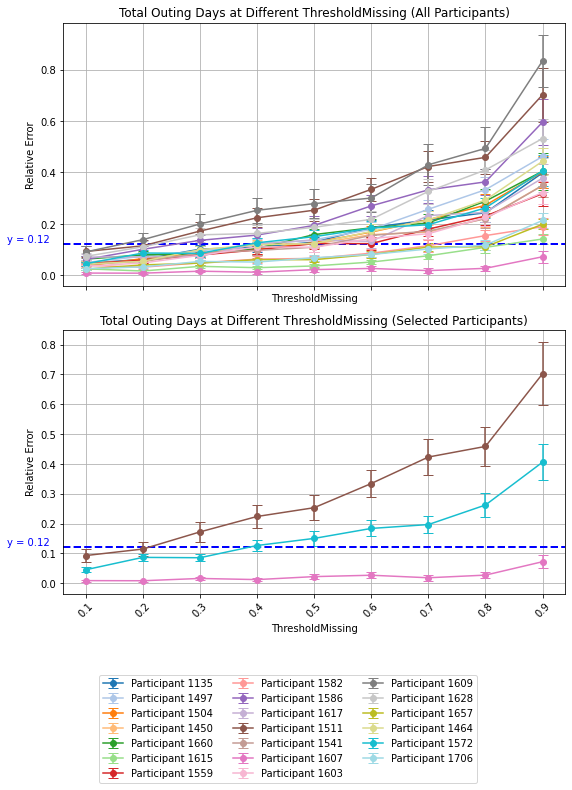

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

def stats_errors_relative(final_result, participants_to_plot=None):
    # Set the font to 'Computer Modern' with specific adjustments
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'font.serif': 'Computer Modern',
        'text.usetex': False
    })

    # Determine all participants if no selection is provided
    all_participants = list(final_result.keys())
    if participants_to_plot is None:
        participants_to_plot = all_participants

    # Define thresholds for plotting on the x-axis
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    # Create a color map with a consistent mapping for participants
    n_colors = len(all_participants)
    colormap = plt.cm.get_cmap('tab20', n_colors)
    color_mapping = {participant: colormap(i % n_colors) for i, participant in enumerate(all_participants)}

    # Initialize the figure with two subplots
    fig, axs = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    # Plot for all participants
    for ax, plot_participants, title in zip(
        axs,
        [all_participants, participants_to_plot],
        ['All Participants', 'Selected Participants']
    ):
        # Initialize dictionaries for storing stats
        updated_confidence_intervals = {}

        for num in plot_participants:
            patient = num
            results = final_result[num]
            updated_confidence_intervals[num] = {}

            for threshold, data in results.items():
                relative_errors = data['relative_errors']

                # Calculate the average error
                mean_relative_error = np.mean(relative_errors)

                # Calculate the standard error of the mean (SEM)
                sem = scipy.stats.sem(relative_errors)

                # Determine the Z-score for a 95% confidence interval
                z_score = scipy.stats.norm.ppf(0.975)  # Two-tailed (for 95% CI)

                # Calculate the margin of error
                margin_of_error = z_score * sem

                # Calculate the confidence interval
                confidence_interval = (mean_relative_error - margin_of_error, mean_relative_error + margin_of_error)

                # Update the dictionaries
                updated_confidence_intervals[num][threshold] = confidence_interval

        # Plot for each participant
        for patient, intervals in updated_confidence_intervals.items():
            # Extract the mean and the confidence interval range (yerr) for each threshold
            means = [(lower + upper) / 2 for lower, upper in intervals.values()]
            yerr = [(mean - lower, upper - mean) for mean, (lower, upper) in zip(means, intervals.values())]

            # Separate the lower and upper errors for yerr
            yerr_lower = [error[0] for error in yerr]
            yerr_upper = [error[1] for error in yerr]

            # Plot error bars
            ax.errorbar(
                thresholds, means, yerr=[yerr_lower, yerr_upper],
                fmt='o-', capsize=5, label=f'Participant {patient}',
                color=color_mapping[patient]
            )

        # Customize each subplot
        ax.set_title(f'Total Outing Days at Different ThresholdMissing ({title})')
        ax.set_xlabel('ThresholdMissing')
        ax.axhline(y=0.12, color='b', linestyle='--', linewidth=2)
        ax.set_ylabel('Relative Error')
        ax.annotate(
            'y = 0.12',
            xy=(0.1, 0.12),
            xytext=(0, 0.12),  # Adjust vertical placement slightly above the line
            color='b',
            fontsize=10,
            ha='center',
            va='bottom',
            annotation_clip=False
        )

        ax.set_xticks(thresholds)
        ax.set_xticklabels(thresholds, rotation=45)
        ax.grid(True)

    # Add a single legend for both subplots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3)

    # Adjust layout
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()
    
    
participants_to_plot = [1511, 1572, 1607]
stats_errors_relative(final_result, participants_to_plot)


In [20]:
# import numpy as np
# import scipy.stats
# import pandas as pd

# thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]


# rows = []
# all_participants = list(final_result.keys())
# for participant in all_participants:
#     results = final_result[participant]

#     for threshold in thresholds:
#         if threshold not in results:
#             continue

#         relative_errors = results[threshold]["relative_errors"]

#         mean_err = np.mean(relative_errors)
#         sem = scipy.stats.sem(relative_errors)
#         z = scipy.stats.norm.ppf(0.975)
#         margin = z * sem

#         rows.append({
#             "participant": participant,
#             "threshold_missing": threshold,
#             "mean_relative_error": mean_err,
#             "ci_lower_95": mean_err - margin,
#             "ci_upper_95": mean_err + margin,
#         })

# df_export = pd.DataFrame(rows)
# df_export.to_excel("plotted_relative_error_data.xlsx", index=False)


In [21]:
# import matplotlib.pyplot as plt

# participants = df_export["participant"].unique()

# plt.figure(figsize=(8, 6))

# for participant in participants:
#     df_p = df_export[df_export["participant"] == participant].sort_values("threshold_missing")

#     x = df_p["threshold_missing"]
#     y = df_p["mean_relative_error"]
#     yerr_lower = y - df_p["ci_lower_95"]
#     yerr_upper = df_p["ci_upper_95"] - y

#     plt.errorbar(
#         x,
#         y,
#         yerr=[yerr_lower, yerr_upper],
#         fmt='o-',
#         capsize=5,
#         label=f"Participant {participant}"
#     )

# # reference line
# plt.axhline(y=0.12, linestyle='--', linewidth=2)
# plt.text(0.1, 0.12, "y = 0.12", va='bottom')

# plt.xlabel("ThresholdMissing")
# plt.ylabel("Relative Error")
# plt.xticks(x)
# plt.title("Relative Error vs ThresholdMissing (from df_export)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()


## Save all mising data 

In [22]:
def read_clinical():
    clinical = pd.read_csv('filtered_clinical.csv', index_col=0)
    # Create a new order for the columns
    new_columns = ['sub_id']+['home_id'] +['study'] +[col for col in clinical.columns if (col != 'home_id' and col !='sub_id' and col != 'study')]
    # Reorder the DataFrame
    clinical = clinical[new_columns]
    
    
    return clinical


clinical=read_clinical()
filtered_clinical=clinical[clinical['home_id'].isin(patients)]
# find info
baseline_info=filtered_clinical[filtered_clinical['redcap_event_name']=='baseline_visit_arm_1']
second_year=filtered_clinical[filtered_clinical['redcap_event_name']=='month_12_arm_1']
third_year=filtered_clinical[filtered_clinical['redcap_event_name']=='month_24_arm_1']

In [23]:
import calendar

# outing_results={}
outing_hrs={}

# 
import random
from collections import defaultdict
# final_result={}

# final_result_hours={}
threshold_levels = [0.1, 0.2, 0.3,0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
missing_info = {}




complete_month={}
for num in patients:
    patient = num
#     outing_results[num]={}
    outing_hrs[num]={}
    missing_info[num] = {}
    
    #read data

    print('patient',num)
    out = readData(patient)
    from datetime import datetime
    left=read_left(patient)
#     visitor=readData_visitor(patient)
   
#     final_result[num]=[]
#     final_result_hours[num]=[]
    #<1> processing data
    #all
    cleaned_data_all=rearrange_sensor_data(out)#rearrange_sensor_data(filter_data(out,visitor,left))
#     print(len(cleaned_data_all))


    #<2> count outing
    #find all outing days
    outing_days=total_outing_improved(left)
    
    
    # get screen date
    patient_screen = second_year.loc[
        second_year['home_id'] == num, 'date_screen'
    ].iloc[0]

    if isinstance(patient_screen, str):
        patient_screen = datetime.strptime(patient_screen, '%Y-%m-%d').date()
    elif isinstance(patient_screen, pd.Timestamp):
        patient_screen = patient_screen.date()


    _, last_day = calendar.monthrange(patient_screen.year, patient_screen.month)
    screen_month_end = patient_screen.replace(day=last_day)

    # truncate 'out' based on patient_screen
    out = [x for x in out if datetime.strptime(x[0], '%d/%m/%Y %H:%M:%S').date() <= screen_month_end]


#     days=count_outing(cleaned_data_all)
 
    # Convert dates to datetime.date objects for easy manipulation-----------use the first 6 months
    dates=readdate(out)
    #     from datetime import datetime, timedelta
    #     start_date = datetime.strptime(dates[0], '%d/%m/%Y').date()
    #     end_date = datetime.strptime(dates[-1], '%d/%m/%Y').date()

    # convert to date objects
    dates_dt = [datetime.strptime(d, '%d/%m/%Y').date() for d in dates]

#     # get first available date
#     start_date = dates_dt[0]

#     # keep only full calendar months (e.g., first 6 months)
#     max_months = 6

#     def month_diff(d1, d2):
#         return (d2.year - d1.year) * 12 + (d2.month - d1.month)

#     dates_dt = [
#         d for d in dates_dt
#         if month_diff(start_date, d) < max_months
#     ]

    # recompute boundaries
    start_date = dates_dt[0]
    end_date = dates_dt[-1]
    
    # date_ranges
    total_days = (end_date - start_date).days + 1
    total_segments = (total_days + 29) // 30  
#     date_ranges = list(generate_date_ranges(start_date, total_segments=total_segments))
    date_ranges = list(generate_monthly_date_ranges(start_date, total_segments=total_segments))
    # Count the days in outing_days for each date range
    counts_in_ranges = count_days_and_hours_in_ranges(date_ranges, outing_days)
    
    
    # Find missing dates within each date range
    missing_dates_by_range = find_missing_dates(date_ranges, cleaned_data_all)
    
    complete_month[num]={}
    for start_date, end_date, count, total_hour in counts_in_ranges:

        for start_date_missing, end_date_missing, missing_dates in missing_dates_by_range:
            if start_date_missing == start_date and start_date.day == 1:
#                 complete_month[num][start_date]=[]
                _, num_days_in_month = calendar.monthrange(start_date.year, start_date.month)
                print(f"From {start_date} to {end_date}, missing dates: {len(missing_dates)}",'num_days_in_month',num_days_in_month)
                # save missing-data statistics
                missing_info[num][start_date] = {
                    "missing_days": len(missing_dates),
                    "num_days_in_month": num_days_in_month,
                    "observed_outing_days": count,
                    "observed_hours": total_hour }
                if len(missing_dates)==0 and count>0:
                    complete_month[num][start_date]=[count,total_hour]

patient 1135
From 2018-07-01 to 2018-07-31, missing dates: 0 num_days_in_month 31
From 2018-08-01 to 2018-08-31, missing dates: 0 num_days_in_month 31
From 2018-09-01 to 2018-09-30, missing dates: 0 num_days_in_month 30
From 2018-10-01 to 2018-10-31, missing dates: 0 num_days_in_month 31
From 2018-11-01 to 2018-11-30, missing dates: 0 num_days_in_month 30
From 2018-12-01 to 2018-12-31, missing dates: 0 num_days_in_month 31
From 2019-01-01 to 2019-01-31, missing dates: 0 num_days_in_month 31
From 2019-02-01 to 2019-02-28, missing dates: 0 num_days_in_month 28
From 2019-03-01 to 2019-03-31, missing dates: 0 num_days_in_month 31
From 2019-04-01 to 2019-04-30, missing dates: 0 num_days_in_month 30
From 2019-05-01 to 2019-05-31, missing dates: 1 num_days_in_month 31
From 2019-06-01 to 2019-06-30, missing dates: 13 num_days_in_month 30
From 2019-07-01 to 2019-07-31, missing dates: 8 num_days_in_month 31
patient 1497
From 2018-07-01 to 2018-07-31, missing dates: 0 num_days_in_month 31
From 20

KeyboardInterrupt: 

In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib.backends.backend_pdf import PdfPages

# pdf_path = "monthly_missing_data.pdf"

# with PdfPages(pdf_path) as pdf:

#     for patient, months in missing_info.items():

#         # sort months chronologically
#         sorted_months = sorted(months.items(), key=lambda x: x[0])

#         month_starts = [m for m, _ in sorted_months]
#         missing_days = [v["missing_days"] for _, v in sorted_months]

#         plt.figure()
#         plt.plot(month_starts, missing_days, marker='o')

#         # annotate values > 0
#         for x, y in zip(month_starts, missing_days):
#             if y > 0:
#                 plt.text(
#                     x, y,
#                     str(y),
#                     ha='center',
#                     va='bottom',
#                     fontsize=9
#                 )

#         plt.title(f"Monthly Missing Data – Patient {patient}")
#         plt.xlabel("Month")
#         plt.ylabel("Number of Missing Days")
#         plt.ylim(0, 32)          # updated range
#         plt.xticks(rotation=45)
#         plt.tight_layout()

#         pdf.savefig()
#         plt.close()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

pdf_path = "complete_vs_missing_months.pdf"

with PdfPages(pdf_path) as pdf:

    for patient in missing_info.keys():  # loop all patients
        # collect all months for this patient
        all_months = set(list(complete_month.get(patient, {}).keys()) +
                         list(missing_info.get(patient, {}).keys()))
        
        # sort months chronologically
        all_months = sorted(all_months)
        
        outing_days_list = []
        missing_days_list = []

        # prepare data
        for m in all_months:
            if m in complete_month.get(patient, {}):
                # complete month: outing days
                outing_days_list.append(complete_month[patient][m][0])
                missing_days_list.append(0)  # no missing
            else:
                outing_days_list.append(0)  # no outing recorded
                # get missing days from missing_info
                missing_days_list.append(missing_info[patient][m]['missing_days'])

        # plot
        plt.figure(figsize=(10,4))
        plt.bar(all_months, outing_days_list, width=20, color='skyblue', label='Outing Days')

        # overlay missing days in red for months without complete data
        for i, m in enumerate(all_months):
            if m not in complete_month.get(patient, {}):
                plt.text(m, missing_days_list[i]/2, str(missing_days_list[i]),
                         color='red', ha='center', va='center', fontsize=10)
                plt.bar(m, missing_days_list[i], width=20, color='lightcoral', alpha=0.7)

        # formatting
        plt.title(f"Patient {patient} – Outing Days (blue) vs Missing Days (red)")
        plt.xlabel("Month")
        plt.ylabel("Days")
        plt.ylim(0, 32)
        plt.xticks(rotation=45)
        plt.legend(['Outing Days', 'Missing Days'])
        plt.tight_layout()

        pdf.savefig()
        plt.close()


In [ ]:
missing_info

In [ ]:
missing_info

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = "complete_vs_missing_months_update.pdf"

with PdfPages(pdf_path) as pdf:

    for patient in missing_info.keys():

        all_months = set(list(complete_month.get(patient, {}).keys()) +
                         list(missing_info.get(patient, {}).keys()))
        all_months = sorted(all_months)

        observed_days = []
        missing_days = []

        for m in all_months:
            if m in complete_month.get(patient, {}):
                # fully observed month
                observed_days.append(complete_month[patient][m][0])
                missing_days.append(0)
            else:
                # partially observed month
                observed = missing_info[patient][m]['observed_outing_days']
                missing = missing_info[patient][m]['missing_days']
                observed_days.append(observed)
                missing_days.append(missing)

        plt.figure(figsize=(10, 4))

        # observed outings (blue)
        plt.bar(all_months, observed_days, width=20, label='Observed outing days')

        # missing days stacked on top (red)
        plt.bar(
            all_months,
            missing_days,
            bottom=observed_days,
            width=20,
            alpha=0.7,
            label='Missing days'
        )

        # annotate missing days
        for i, m in enumerate(all_months):
            if missing_days[i] > 0:
                plt.text(
                    m,
                    observed_days[i] + missing_days[i] / 2,
                    str(missing_days[i]),
                    ha='center',
                    va='center',
                    fontsize=9,
                    color='darkred'
                )

        plt.title(f"Patient {patient}: Observed vs Missing Days per Month")
        plt.xlabel("Month")
        plt.ylabel("Days")
        plt.ylim(0, 32)
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()

        pdf.savefig()
        plt.close()

In [ ]:
import scipy.stats

In [ ]:
# patients=[1135, 1450, 1464, 1497, 1498, 1504, 1506, 1508, 1511, 1514, 1522, 1526, 1540, 1541]

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.stats

# def stats_errors(string, final_result):
#     # Set the font to 'Computer Modern' with specific adjustments
#     plt.rcParams.update({
#         'font.size': 12,
#         'font.family': 'serif',
#         'font.serif': 'Computer Modern',
#         'text.usetex': False
#     })


#     plt.figure(figsize=(36, 16))

#     # Initialize the dictionaries
#     updated_avg = {}
#     updated_confidence_intervals = {}
#     for num in patients:
#         patient = num

#         results = final_result[num]
#         updated_avg[num] = {}
#         updated_confidence_intervals[num] = {}

#         for threshold, data in results.items():
#             if string == 'Relative Errors':
#                 relative_errors = data['relative_errors']
#             else:
#                 relative_errors = data['errors']
            
#             # Calculate the average error
#             mean_relative_error = np.mean(relative_errors)

#             # Calculate the standard error of the mean (SEM)
#             sem = scipy.stats.sem(relative_errors)

#             # Determine the Z-score for a 95% confidence interval
#             z_score = scipy.stats.norm.ppf(0.975)  # Two-tailed (for 95% CI)

#             # Calculate the margin of error
#             margin_of_error = z_score * sem

#             # Calculate the confidence interval
#             confidence_interval = (mean_relative_error - margin_of_error, mean_relative_error + margin_of_error)

#             # Update the dictionaries
#             updated_avg[num][threshold] = mean_relative_error
#             updated_confidence_intervals[num][threshold] = confidence_interval

#     # Define thresholds for plotting on the x-axis
#     thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

#     # Create a color map with a sufficient number of colors
#     n_colors = len(updated_confidence_intervals)
#     colormap = plt.cm.get_cmap('tab20', n_colors)

#     # Generate a color for each patient by creating a mapping
#     # If there are more patients than colors, this will cycle through the colormap
#     color_mapping = {patient: colormap(i % n_colors) for i, patient in enumerate(updated_confidence_intervals)}

#     # Start plotting
#     fig, ax = plt.subplots()
    
#     # Plot for each patient
#     for patient, intervals in updated_confidence_intervals.items():
#         # Extract the mean and the confidence interval range (yerr) for each threshold
#         means = [(lower + upper) / 2 for lower, upper in intervals.values()]
#         yerr = [(mean - lower, upper - mean) for mean, (lower, upper) in zip(means, intervals.values())]

#         # Error bars require a single value for each limit, so we separate the lower and upper values
#         yerr_lower = [error[0] for error in yerr]
#         yerr_upper = [error[1] for error in yerr]
        
#         # Plot error bars
#         ax.errorbar(thresholds, means, yerr=[yerr_lower, yerr_upper], fmt='o-', capsize=5, label=f'Participant {patient}', color=color_mapping[patient])
   
# #     # Customize the plot
# #     ax.set_title('Total Outing Days for Each Participant at Different ThresholdMissing')
# #     ax.set_xlabel('ThresholdMissing')
    
# #     # Customize the y-label based on the type of errors
# #     if string == 'Errors':
# #         # Adding a horizontal line at y=3
# #         plt.axhline(y=3, color='r', linestyle='--', linewidth=2, label='y = 3')
# #         ax.set_ylabel(string)
# #     elif string == 'Relative Errors':
# #         plt.axhline(y=0.12, color='b', linestyle='--', linewidth=2, label='y = 0.12')
# #         ax.set_ylabel('Relative Errors')

# #     ax.set_xticks(thresholds)
# #     ax.set_xticklabels(thresholds, rotation=45)
# #     ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.96), ncol=3)  # Move legend to the bottom
# #     ax.grid(True)

# #     # Show the plot
# #     plt.show()

#     # Customize the plot
#     ax.set_title('Total outing days for each participant at different ThresholdMissing')
#     ax.set_xlabel('ThresholdMissing')

#     # Customize the y-label based on the type of errors
#     if string == 'Errors':
#         # Adding a horizontal line at y=3
#         plt.axhline(y=3, color='r', linestyle='--', linewidth=2, label='y = 3')
#         ax.set_ylabel(string)
#         # Add label on the y-axis
#         ax.annotate('y = 3', xy=(0, 3), xytext=(-0.5, 3), color='r', fontsize=10, ha='right', va='center', annotation_clip=False)

#     elif string == 'Relative Errors':
#         # Adding a horizontal line at y=0.12
#         plt.axhline(y=0.12, color='b', linestyle='--', linewidth=2, label='y = 0.12')
#         ax.set_ylabel('Relative Error')
#         # Add label on the y-axis
#         ax.annotate('y = 0.12', xy=(0, 0.12), xytext=(0, 0.12), color='b', fontsize=10, ha='right', va='center', annotation_clip=False)

#     ax.set_xticks(thresholds)
#     ax.set_xticklabels(thresholds, rotation=45)
#     ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.96), ncol=3)  # Move legend to the bottom
#     ax.grid(True)

#     # Show the plot
#     plt.show()

In [ ]:
# stats_errors('Relative Errors',final_result)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.stats

# def stats_errors(string, final_result):
#     # Set the font to 'Computer Modern' with specific adjustments
#     plt.rcParams.update({
#         'font.size': 12,
#         'font.family': 'serif',
#         'font.serif': 'Computer Modern',
#         'text.usetex': False
#     })

#     # Specify the participants you want to plot
#     participants_to_plot = [1511, 1572, 1607]

#     # Initialize the dictionaries for storing stats
#     updated_avg = {}
#     updated_confidence_intervals = {}

#     for num in participants_to_plot:
#         patient = num
#         results = final_result[num]
#         updated_avg[num] = {}
#         updated_confidence_intervals[num] = {}

#         for threshold, data in results.items():
#             if string == 'Relative Errors':
#                 relative_errors = data['relative_errors']
#             else:
#                 relative_errors = data['errors']
            
#             # Calculate the average error
#             mean_relative_error = np.mean(relative_errors)

#             # Calculate the standard error of the mean (SEM)
#             sem = scipy.stats.sem(relative_errors)

#             # Determine the Z-score for a 95% confidence interval
#             z_score = scipy.stats.norm.ppf(0.975)  # Two-tailed (for 95% CI)

#             # Calculate the margin of error
#             margin_of_error = z_score * sem

#             # Calculate the confidence interval
#             confidence_interval = (mean_relative_error - margin_of_error, mean_relative_error + margin_of_error)

#             # Update the dictionaries
#             updated_avg[num][threshold] = mean_relative_error
#             updated_confidence_intervals[num][threshold] = confidence_interval

#     # Define thresholds for plotting on the x-axis
#     thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

#     # Create a color map with a sufficient number of colors
#     n_colors = len(participants_to_plot)
#     colormap = plt.cm.get_cmap('tab10', n_colors)

#     # Generate a color for each participant
#     color_mapping = {participant: colormap(i % n_colors) for i, participant in enumerate(participants_to_plot)}

#     # Start plotting
#     fig, ax = plt.subplots(figsize=(6, 4))
# #      plt.figure(figsize=(36, 16))
#     # Plot for each selected participant
#     for patient, intervals in updated_confidence_intervals.items():
#         # Extract the mean and the confidence interval range (yerr) for each threshold
#         means = [(lower + upper) / 2 for lower, upper in intervals.values()]
#         yerr = [(mean - lower, upper - mean) for mean, (lower, upper) in zip(means, intervals.values())]

#         # Separate the lower and upper errors for yerr
#         yerr_lower = [error[0] for error in yerr]
#         yerr_upper = [error[1] for error in yerr]
        
#         # Plot error bars
#         ax.errorbar(
#             thresholds, means, yerr=[yerr_lower, yerr_upper],
#             fmt='o-', capsize=5, label=f'Participant {patient}',
#             color=color_mapping[patient]
#         )
    
#     # Customize the plot
#     ax.set_title('Total outing days for selected participants at different ThresholdMissing')
#     ax.set_xlabel('ThresholdMissing')

#     # Customize the y-label and horizontal line based on the type of errors
#     if string == 'Errors':
#         plt.axhline(y=3, color='r', linestyle='--', linewidth=2, label='y = 3')
#         ax.set_ylabel('Errors')
#         ax.annotate(
#             'y = 3', 
#             xy=(0.1, 3), 
#             xytext=(0.1, 3.2),  # Adjust vertical placement slightly above the line
#             color='r', 
#             fontsize=10, 
#             ha='center', 
#             va='bottom', 
#             annotation_clip=False
#         )
#     elif string == 'Relative Errors':
#         plt.axhline(y=0.12, color='b', linestyle='--', linewidth=2, label='y = 0.12')
#         ax.set_ylabel('Relative Error')
#         ax.annotate(
#             'y = 0.12', 
#             xy=(0.1, 0.12), 
#             xytext=(0, 0.13),  # Adjust vertical placement slightly above the line
#             color='b', 
#             fontsize=10, 
#             ha='center', 
#             va='bottom', 
#             annotation_clip=False
#         )

#     ax.set_xticks(thresholds)
#     ax.set_xticklabels(thresholds, rotation=45)
#     ax.legend(loc='lower center', bbox_to_anchor=(0.5, -1.26), ncol=3) 
#     ax.grid(True)

#     plt.tight_layout()
#     plt.show()

In [ ]:
# stats_errors('Relative Errors', final_result)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.stats

# def stats_errors(string, final_result):
#     # Set the default font to Arial and size to 12 for all elements in the plot
#     plt.rcParams.update({
#         'font.size': 12,
#         'font.family': 'sans-serif',
#         'font.sans-serif': 'Computer Modern'
#     })

#     # Assuming 'final_result' and 'patients' are defined, and actual outings are known and stored in a variable.
#     plt.figure(figsize=(26, 16))

#     # Initialize the dictionaries
#     updated_avg = {}
#     updated_confidence_intervals = {}
#     for num in patients:
#         patient = num

#         results = final_result[num]
#         updated_avg[num] = {}
#         updated_confidence_intervals[num] = {}

#         for threshold, data in results.items():
#             if string == 'Relative Errors':
#                 relative_errors = data['relative_errors']
#             else:
#                 relative_errors = data['errors']
            
#             # Calculate the average error
#             mean_relative_error = np.mean(relative_errors)

#             # Calculate the standard error of the mean (SEM)
#             sem = scipy.stats.sem(relative_errors)

#             # Determine the Z-score for a 95% confidence interval
#             z_score = scipy.stats.norm.ppf(0.975)  # Two-tailed (for 95% CI)

#             # Calculate the margin of error
#             margin_of_error = z_score * sem

#             # Calculate the confidence interval
#             confidence_interval = (mean_relative_error - margin_of_error, mean_relative_error + margin_of_error)

#             # Update the dictionaries
#             updated_avg[num][threshold] = mean_relative_error
#             updated_confidence_intervals[num][threshold] = confidence_interval

#     # Define thresholds for plotting on the x-axis
#     thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

#     # Create a color map with a sufficient number of colors
#     n_colors = len(updated_confidence_intervals)
#     colormap = plt.cm.get_cmap('tab20', n_colors)

#     # Generate a color for each patient by creating a mapping
#     # If there are more patients than colors, this will cycle through the colormap
#     color_mapping = {patient: colormap(i % n_colors) for i, patient in enumerate(updated_confidence_intervals)}

#     # Start plotting
#     fig, ax = plt.subplots()
    
#     # Plot for each patient
#     for patient, intervals in updated_confidence_intervals.items():
#         # Extract the mean and the confidence interval range (yerr) for each threshold
#         means = [(lower + upper) / 2 for lower, upper in intervals.values()]
#         yerr = [(mean - lower, upper - mean) for mean, (lower, upper) in zip(means, intervals.values())]

#         # Error bars require a single value for each limit, so we separate the lower and upper values
#         yerr_lower = [error[0] for error in yerr]
#         yerr_upper = [error[1] for error in yerr]
        
#         # Plot error bars
#         ax.errorbar(thresholds, means, yerr=[yerr_lower, yerr_upper], fmt='o-', capsize=5, label=f'Patient {patient}', color=color_mapping[patient])
   
#     # Customize the plot
#     ax.set_title('Total Outing Days for Each Patient at Different Thresholds',fontweight="bold")
#     ax.set_xlabel('Threshold')
#     if string == 'Errors':
#         # Adding a horizontal line at y=3
#         plt.axhline(y=3, color='r', linestyle='--', linewidth=2, label='y = 3')
#         ax.set_ylabel(string)
#     if string == 'Relative Errors':
#         plt.axhline(y=0.11, color='b', linestyle='--', linewidth=2, label='y = 0.11')
# #         plt.axhline(y=0.11, color='r', linestyle='--', linewidth=2, label='y = 0.12')
#         ax.set_ylabel('Relative Errors')

#     ax.set_xticks(thresholds)
#     ax.set_xticklabels(thresholds, rotation=45)
#     ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.86), ncol=3)  # Move legend to the bottom
#     ax.grid(True)

#     # Show the plot
#     plt.show()


In [ ]:
# stats_errors_hours('Relative Errors',final_result_hours)

In [ ]:
# stats_errors_hours('Errors',final_result_hours)

In [ ]:
# patients=[1135, 1497, 1504, 1511, 1603, 1607, 1609, 
#           1615, 1617, 1628, 1657] 

In [24]:
final_results={}
for k,v in final_result.items():
    if k in patients:
        final_results[k]=v

In [25]:
# MCI_patients= [1464, 1508, 1511, 1603, 1609, 1607, 1628, 1657, 1665, 1724]

In [26]:
# remove_patient=[]
# for num in patients:
#     if num not in MCI_patients:
#         month_data=[a[0] for a in list(complete_month[num].values())]
#         max_month_data=max(month_data)
#         if max_month_data <= 10:
#             print(num, max_month_data,"\n")
#             remove_patient.append(num)

In [27]:
# patients=[a for a in patients if a not in remove_patient]
# print(patients)

In [28]:
len(final_results.keys())

20

# proration

In [29]:
def find_max_mean_relative_error_at_threshold(final_results, target_threshold=0.1):
    """
    Calculate the maximum of mean relative errors for all patients at a specific threshold.

    Args:
    final_results (dict): The dictionary containing relative error data organized by patient and threshold.
    target_threshold (float): The threshold to analyze.

    Returns:
    float: The maximum of the mean relative errors at the specified threshold, or None if no data available.
    """
    # Collecting data for the specific threshold
    data = []
    for patient, thresholds in final_results.items():
        if target_threshold in thresholds:  # Check if the target threshold is present
            metrics = thresholds[target_threshold]
            for rel_error in metrics['relative_errors']:
                data.append((patient, target_threshold, rel_error))

    # Create a DataFrame
    df = pd.DataFrame(data, columns=['Patient', 'Threshold', 'Relative Errors'])

    # If DataFrame is empty, return None indicating no data was found
    if df.empty:
        return None

    # Calculate the mean of 'Relative Errors' for each 'Patient' at the specific threshold
    df['Mean Relative Errors'] = df.groupby('Patient')['Relative Errors'].transform(np.mean)

    # Find the maximum mean relative error
    max_mean_relative_error = df['Mean Relative Errors'].max()

    return (math.ceil(max_mean_relative_error*100)/100)

In [36]:
relative_error_rate=find_max_mean_relative_error_at_threshold(final_results, target_threshold=0.1)
relative_error_rate

0.1

In [31]:
if relative_error_rate>0.1:
    relative_error_rate=relative_error_rate
else:
    relative_error_rate=0.1
    
relative_error_rate

0.1

In [32]:
def find_max(final_result,relative_error_rate):
    # Flattening the dictionary to a list suitable for DataFrame
    data = []
    for patient, thresholds in final_result.items():
        for threshold, metrics in thresholds.items():
            for rel_error in metrics['relative_errors']:
                data.append((patient, threshold, rel_error))

    # Columns: Patient, Threshold, Relative Errors
    df = pd.DataFrame(data, columns=['Patient', 'Threshold', 'Relative Errors'])


    # Calculate the mean of 'Relative Errors' for each 'Patient' and 'Threshold'
    mean_relative_errors = df.groupby(['Patient', 'Threshold'])['Relative Errors'].mean().reset_index()
    # mean_relative_errors

    # Filter to find where mean Relative Errors are < 0.1
    filtered_means = mean_relative_errors[mean_relative_errors['Relative Errors'] < relative_error_rate]
    # filtered_means
    # # Group by Patient and collect relevant Thresholds
    grouped_df = filtered_means.groupby('Patient')['Threshold'].apply(list).reset_index()
    # grouped_df

    # Calculate max Threshold for each Patient directly
    max_threshold_df = filtered_means.groupby('Patient')['Threshold'].max().reset_index()
    
    # Convert DataFrame to dictionary 
    max_threshold_df.set_index('Patient', inplace=True)
    max_threshold_days = max_threshold_df['Threshold'].to_dict()

    
    return max_threshold_days

In [33]:
len(final_results.keys())

20

In [37]:
#max threshold days,relative_error_rate=0.11
max_threshold_days=find_max(final_results,relative_error_rate)
print(max_threshold_days)

{1135: 0.2, 1450: 0.3, 1464: 0.2, 1497: 0.3, 1504: 0.3, 1511: 0.1, 1541: 0.4, 1559: 0.4, 1572: 0.3, 1582: 0.6, 1586: 0.1, 1603: 0.3, 1607: 0.9, 1609: 0.1, 1615: 0.7, 1617: 0.3, 1628: 0.1, 1657: 0.6, 1660: 0.3, 1706: 0.6}


In [35]:
# #max threshold days,relative_error_rate=0.12
# relative_error_rate=0.12
# max_threshold_days=find_max(final_results,relative_error_rate)
# print(max_threshold_days)

{1135: 0.4, 1450: 0.3, 1464: 0.4, 1497: 0.3, 1504: 0.4, 1511: 0.2, 1541: 0.5, 1559: 0.4, 1572: 0.3, 1582: 0.7, 1586: 0.2, 1603: 0.5, 1607: 0.9, 1609: 0.1, 1615: 0.8, 1617: 0.3, 1628: 0.2, 1657: 0.8, 1660: 0.4, 1706: 0.8}


In [ ]:
len(max_threshold_days.keys())

In [ ]:
# import csv
# # Specify the filename
# filename = 'max_threshold_days(relative_errors=0.2).csv'

# # Writing to a CSV file
# with open(filename, mode='w', newline='') as file:
#     writer = csv.writer(file)
#     # Write the headers
#     writer.writerow(['ID', 'Threshold'])
#     # Write the data
#     for id, threshold in max_threshold_days.items():
#         writer.writerow([id, threshold])


In [38]:
# New analysis --- percentage of using each option
import calendar

outing_results={}
outing_hrs={}
option_usage={}

for num in patients:
    patient = num
    outing_results[num]={}
    outing_hrs[num]={}
    #read data
    print('patient',num)
    out = readData(patient)
    option_usage[num] = {}

  
    
    from datetime import datetime
    left=read_left(patient)
#     visitor=readData_visitor(patient)
   
    
    #<1> processing data
    #all
    cleaned_data_all=rearrange_sensor_data(out)#rearrange_sensor_data(filter_data(out,visitor,left))
#     print(len(cleaned_data_all))


    #<2> count outing
    #find all outing days
    outing_days=total_outing_improved(left)


#     days=count_outing(cleaned_data_all)
 
#     # Convert dates to datetime.date objects for easy manipulation
#     dates=readdate(out)
    
    # get screen date
    patient_screen = second_year.loc[
        second_year['home_id'] == num, 'date_screen'
    ].iloc[0]

    if isinstance(patient_screen, str):
        patient_screen = datetime.strptime(patient_screen, '%Y-%m-%d').date()
    elif isinstance(patient_screen, pd.Timestamp):
        patient_screen = patient_screen.date()


    _, last_day = calendar.monthrange(patient_screen.year, patient_screen.month)
    screen_month_end = patient_screen.replace(day=last_day)

    # truncate 'out' based on patient_screen
    out = [x for x in out if datetime.strptime(x[0], '%d/%m/%Y %H:%M:%S').date() <= screen_month_end]


#     days=count_outing(cleaned_data_all)
 
    # Convert dates to datetime.date objects for easy manipulation-----------use the first 6 months
    dates=readdate(out)
    #     from datetime import datetime, timedelta
    #     start_date = datetime.strptime(dates[0], '%d/%m/%Y').date()
    #     end_date = datetime.strptime(dates[-1], '%d/%m/%Y').date()

    # convert to date objects
    dates_dt = [datetime.strptime(d, '%d/%m/%Y').date() for d in dates]

    
    
    
    from datetime import datetime, timedelta
    start_date = datetime.strptime(dates[0], '%d/%m/%Y').date()
    end_date = datetime.strptime(dates[-1], '%d/%m/%Y').date()
    
    
    # date_ranges
    total_days = (end_date - start_date).days + 1
    total_segments = (total_days + 29) // 30  
    date_ranges = list(generate_monthly_date_ranges(start_date, total_segments=total_segments))
    # Count the days in outing_days for each date range
    counts_in_ranges = count_days_and_hours_in_ranges(date_ranges, outing_days)
    
    
    # Find missing dates within each date range
    missing_dates_by_range = find_missing_dates(date_ranges, cleaned_data_all)
    
    
    # Output the results
    outing_dates=[]
    for start_date, end_date, count,total_hour in counts_in_ranges:
        
        for start_date_missing, end_date_missing, missing_dates in missing_dates_by_range:
            if start_date_missing==start_date and start_date.day == 1:
                _, num_days_in_month = calendar.monthrange(start_date.year, start_date.month)
                
               
                print(f"From {start_date} to {end_date}, number of outing days: {count}","total_hour",total_hour)
                print(f"From {start_date} to {end_date}, missing dates: {len(missing_dates)}",'num_days_in_month',num_days_in_month)
                
                
                # (1) number of days
                missing_threshold_days = math.floor(max_threshold_days[num]*num_days_in_month)
                print('missing_threshold_days',max_threshold_days[num],missing_threshold_days)
    
                    # Check if count_hrs is greater than half the range length in days
                if len(missing_dates) == 0 and count > 0:
                    # FULL month — no proration
                    option_usage[num][start_date] = "Full"
                    outing_results[num][start_date] = (count, total_hour)

                elif len(missing_dates) <= missing_threshold_days and count >0:
                       #added
                        option_usage[num][start_date] = "Option1"
                        remaining_days=num_days_in_month-len(missing_dates)
                        weighted_outing=math.floor(count*num_days_in_month/(remaining_days))
    #                     print('weighted outing',weighted_outing)

                    # (2) Calculate the new pro-rated total hours
    #                    pro_rated_total_hrs = math.ceil(total_hour * weighted_outing / count)
                        pro_rated_total_hrs = math.floor(total_hour * num_days_in_month / remaining_days)
    #                     print('pro_rated_total_hrs',pro_rated_total_hrs)
                        outing_results[num][start_date]=(weighted_outing,pro_rated_total_hrs)
                else:
#                     print("Not enough data")
                    option_usage[num][start_date] = "Option2"
                    outing_results[num][start_date]=None


patient 1135
From 2018-07-01 to 2018-07-31, number of outing days: 17 total_hour 25.569999999999997
From 2018-07-01 to 2018-07-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.2 6
From 2018-08-01 to 2018-08-31, number of outing days: 16 total_hour 20.750000000000004
From 2018-08-01 to 2018-08-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.2 6
From 2018-09-01 to 2018-09-30, number of outing days: 16 total_hour 15.45
From 2018-09-01 to 2018-09-30, missing dates: 0 num_days_in_month 30
missing_threshold_days 0.2 6
From 2018-10-01 to 2018-10-31, number of outing days: 19 total_hour 18.58
From 2018-10-01 to 2018-10-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.2 6
From 2018-11-01 to 2018-11-30, number of outing days: 11 total_hour 14.209999999999997
From 2018-11-01 to 2018-11-30, missing dates: 0 num_days_in_month 30
missing_threshold_days 0.2 6
From 2018-12-01 to 2018-12-31, number of outing days: 18 total_hour 20.470000000000002
F

From 2019-02-01 to 2019-02-28, number of outing days: 11 total_hour 9.61
From 2019-02-01 to 2019-02-28, missing dates: 0 num_days_in_month 28
missing_threshold_days 0.3 8
From 2019-03-01 to 2019-03-31, number of outing days: 8 total_hour 7.62
From 2019-03-01 to 2019-03-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.3 9
From 2019-04-01 to 2019-04-30, number of outing days: 21 total_hour 23.040000000000006
From 2019-04-01 to 2019-04-30, missing dates: 0 num_days_in_month 30
missing_threshold_days 0.3 9
From 2019-05-01 to 2019-05-31, number of outing days: 17 total_hour 15.129999999999997
From 2019-05-01 to 2019-05-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.3 9
From 2019-06-01 to 2019-06-30, number of outing days: 12 total_hour 16.23
From 2019-06-01 to 2019-06-30, missing dates: 2 num_days_in_month 30
missing_threshold_days 0.3 9
From 2019-07-01 to 2019-07-31, number of outing days: 21 total_hour 20.4
From 2019-07-01 to 2019-07-31, missing dates

From 2018-12-01 to 2018-12-31, number of outing days: 15 total_hour 57.1
From 2018-12-01 to 2018-12-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.3 9
From 2019-01-01 to 2019-01-31, number of outing days: 9 total_hour 14.009999999999998
From 2019-01-01 to 2019-01-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.3 9
From 2019-02-01 to 2019-02-28, number of outing days: 21 total_hour 36.35
From 2019-02-01 to 2019-02-28, missing dates: 0 num_days_in_month 28
missing_threshold_days 0.3 8
From 2019-03-01 to 2019-03-31, number of outing days: 20 total_hour 68.78
From 2019-03-01 to 2019-03-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.3 9
From 2019-04-01 to 2019-04-30, number of outing days: 18 total_hour 32.78
From 2019-04-01 to 2019-04-30, missing dates: 0 num_days_in_month 30
missing_threshold_days 0.3 9
From 2019-05-01 to 2019-05-31, number of outing days: 7 total_hour 8.99
From 2019-05-01 to 2019-05-31, missing dates: 0 num_days_

From 2019-01-01 to 2019-01-31, number of outing days: 8 total_hour 9.59
From 2019-01-01 to 2019-01-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.1 3
From 2019-02-01 to 2019-02-28, number of outing days: 4 total_hour 8.08
From 2019-02-01 to 2019-02-28, missing dates: 0 num_days_in_month 28
missing_threshold_days 0.1 2
From 2019-03-01 to 2019-03-31, number of outing days: 9 total_hour 15.179999999999998
From 2019-03-01 to 2019-03-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.1 3
From 2019-04-01 to 2019-04-30, number of outing days: 3 total_hour 2.86
From 2019-04-01 to 2019-04-30, missing dates: 0 num_days_in_month 30
missing_threshold_days 0.1 3
From 2019-05-01 to 2019-05-31, number of outing days: 9 total_hour 10.91
From 2019-05-01 to 2019-05-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.1 3
From 2019-06-01 to 2019-06-30, number of outing days: 0 total_hour 0
From 2019-06-01 to 2019-06-30, missing dates: 28 num_days_in_month

From 2019-03-01 to 2019-03-31, number of outing days: 24 total_hour 50.07999999999999
From 2019-03-01 to 2019-03-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.6 18
From 2019-04-01 to 2019-04-30, number of outing days: 24 total_hour 42.13000000000001
From 2019-04-01 to 2019-04-30, missing dates: 0 num_days_in_month 30
missing_threshold_days 0.6 18
From 2019-05-01 to 2019-05-31, number of outing days: 27 total_hour 70.35000000000001
From 2019-05-01 to 2019-05-31, missing dates: 0 num_days_in_month 31
missing_threshold_days 0.6 18
From 2019-06-01 to 2019-06-30, number of outing days: 4 total_hour 23.509999999999998
From 2019-06-01 to 2019-06-30, missing dates: 26 num_days_in_month 30
missing_threshold_days 0.6 18
From 2019-07-01 to 2019-07-31, number of outing days: 0 total_hour 0
From 2019-07-01 to 2019-07-31, missing dates: 31 num_days_in_month 31
missing_threshold_days 0.6 18
From 2019-08-01 to 2019-08-31, number of outing days: 22 total_hour 36.769999999999996
Fro

In [39]:
complete_months = 0
option1_months = 0
option2_months = 0

for num, months in option_usage.items():
    for opt in months.values():
        if opt == "Full":
            complete_months += 1
        elif opt == "Option1":
            option1_months += 1
        elif opt == "Option2":
            option2_months += 1


In [40]:
option_usage

{1135: {datetime.date(2018, 7, 1): 'Full',
  datetime.date(2018, 8, 1): 'Full',
  datetime.date(2018, 9, 1): 'Full',
  datetime.date(2018, 10, 1): 'Full',
  datetime.date(2018, 11, 1): 'Full',
  datetime.date(2018, 12, 1): 'Full',
  datetime.date(2019, 1, 1): 'Full',
  datetime.date(2019, 2, 1): 'Full',
  datetime.date(2019, 3, 1): 'Full',
  datetime.date(2019, 4, 1): 'Full',
  datetime.date(2019, 5, 1): 'Option1',
  datetime.date(2019, 6, 1): 'Option2',
  datetime.date(2019, 7, 1): 'Option2'},
 1497: {datetime.date(2018, 7, 1): 'Full',
  datetime.date(2018, 8, 1): 'Full',
  datetime.date(2018, 9, 1): 'Full',
  datetime.date(2018, 10, 1): 'Full',
  datetime.date(2018, 11, 1): 'Full',
  datetime.date(2018, 12, 1): 'Option1',
  datetime.date(2019, 1, 1): 'Full',
  datetime.date(2019, 2, 1): 'Full',
  datetime.date(2019, 3, 1): 'Full',
  datetime.date(2019, 4, 1): 'Full',
  datetime.date(2019, 5, 1): 'Full'},
 1504: {datetime.date(2018, 8, 1): 'Option1',
  datetime.date(2018, 9, 1): 'Full

In [85]:
with open("option_usage.txt", "w") as f:
    for patient_id, usage in option_usage.items():
        f.write(f"Participant {patient_id}:\n")
        for d in sorted(usage.keys()):
            year_month = f"{d.year}-{d.month:02d}"
            f.write(f"  {year_month}: {usage[d]}\n")
        f.write("\n")

In [41]:
from collections import defaultdict

# Store counts per participant
option_summary = {}

for patient_id, usage in option_usage.items():
    counts = {
        "Option1": 0,
        "Option2": 0,
        "Full": 0,
        "Total": 0
    }
    
    for month, option in usage.items():
        counts["Total"] += 1
        if option in counts:
            counts[option] += 1
    
    option_summary[patient_id] = counts

# Print results
for pid, counts in option_summary.items():
    print(
        f"Patient {pid}: "
        f"Full={counts['Full']}, "
        f"Option1={counts['Option1']}, "
        f"Option2={counts['Option2']}, "
        f"Total={counts['Total']}"
    )


Patient 1135: Full=10, Option1=1, Option2=2, Total=13
Patient 1497: Full=10, Option1=1, Option2=0, Total=11
Patient 1504: Full=8, Option1=2, Option2=1, Total=11
Patient 1450: Full=5, Option1=5, Option2=2, Total=12
Patient 1660: Full=9, Option1=1, Option2=0, Total=10
Patient 1615: Full=10, Option1=1, Option2=0, Total=11
Patient 1559: Full=9, Option1=0, Option2=2, Total=11
Patient 1582: Full=7, Option1=4, Option2=1, Total=12
Patient 1586: Full=6, Option1=1, Option2=3, Total=10
Patient 1617: Full=9, Option1=1, Option2=2, Total=12
Patient 1511: Full=9, Option1=2, Option2=0, Total=11
Patient 1541: Full=7, Option1=2, Option2=1, Total=10
Patient 1607: Full=4, Option1=3, Option2=2, Total=9
Patient 1603: Full=6, Option1=1, Option2=2, Total=9
Patient 1609: Full=9, Option1=0, Option2=2, Total=11
Patient 1628: Full=8, Option1=0, Option2=1, Total=9
Patient 1657: Full=8, Option1=3, Option2=0, Total=11
Patient 1464: Full=6, Option1=4, Option2=2, Total=12
Patient 1572: Full=8, Option1=0, Option2=2, To

In [62]:
option_summary

{1135: {'Option1': 1, 'Option2': 2, 'Full': 10, 'Total': 13},
 1497: {'Option1': 1, 'Option2': 0, 'Full': 10, 'Total': 11},
 1504: {'Option1': 2, 'Option2': 1, 'Full': 8, 'Total': 11},
 1450: {'Option1': 5, 'Option2': 2, 'Full': 5, 'Total': 12},
 1660: {'Option1': 1, 'Option2': 0, 'Full': 9, 'Total': 10},
 1615: {'Option1': 1, 'Option2': 0, 'Full': 10, 'Total': 11},
 1559: {'Option1': 0, 'Option2': 2, 'Full': 9, 'Total': 11},
 1582: {'Option1': 4, 'Option2': 1, 'Full': 7, 'Total': 12},
 1586: {'Option1': 1, 'Option2': 3, 'Full': 6, 'Total': 10},
 1617: {'Option1': 1, 'Option2': 2, 'Full': 9, 'Total': 12},
 1511: {'Option1': 2, 'Option2': 0, 'Full': 9, 'Total': 11},
 1541: {'Option1': 2, 'Option2': 1, 'Full': 7, 'Total': 10},
 1607: {'Option1': 3, 'Option2': 2, 'Full': 4, 'Total': 9},
 1603: {'Option1': 1, 'Option2': 2, 'Full': 6, 'Total': 9},
 1609: {'Option1': 0, 'Option2': 2, 'Full': 9, 'Total': 11},
 1628: {'Option1': 0, 'Option2': 1, 'Full': 8, 'Total': 9},
 1657: {'Option1': 3, 'O

In [53]:
from collections import defaultdict

# Store counts per patient
sequence_counts = defaultdict(int)

for patient_id, usage in option_usage.items():
    # Sort months
    months_sorted = sorted(usage.keys())
    for i in range(len(months_sorted)-1):
        current_month = months_sorted[i]
        next_month = months_sorted[i+1]
        current_option = usage[current_month]
        next_option = usage[next_month]
        
        # Check if current or next month has Option1/Option2
        if current_option in ['Option1', 'Option2'] and next_option in ['Option2']:
            sequence_counts[patient_id] += 1

# # Example output
for pid, count in sequence_counts.items():
    print(pid, count )


1135 2
1450 2
1559 1
1582 1
1586 2
1617 1
1541 1
1607 2
1603 2
1609 1
1572 1
1706 2


In [54]:
special_case=sum(sequence_counts.values())
special_case

18

In [55]:
complete_months,option1_months,option2_months

(153, 35, 29)

In [56]:
total = complete_months+option1_months+option2_months
total

217

In [57]:
round(complete_months/total*100,2),round(option1_months/total*100,2),round(option2_months/total*100,2)

(70.51, 16.13, 13.36)

In [58]:
round(special_case/total*100,2)

8.29

In [ ]:
xx

In [80]:
from collections import defaultdict

user_counts = defaultdict(lambda: {
    'Full': 0,
    'Option1': 0,
    'Option2': 0
})


# Count months per user
for patient_id, usage in option_usage.items():
    for option in usage.values():
        if option in user_counts[patient_id]:
            user_counts[patient_id][option] += 1

user_ratios = {}

for patient_id, counts in user_counts.items():
    total = counts['Full'] + counts['Option1'] + counts['Option2']

    if total == 0:
        user_ratios[patient_id] = {
            'Full_ratio': 0,
            'Option1_ratio': 0,
            'Option2_ratio': 0
        }
    else:
        user_ratios[patient_id] = {
            'Full_ratio': round(counts['Full'] / total * 100, 2),
            'Option1_ratio': round(counts['Option1'] / total * 100, 2),
            'Option2_ratio': round(counts['Option2'] / total * 100, 2)
        }


In [81]:
user_ratios

{1135: {'Full_ratio': 76.92, 'Option1_ratio': 7.69, 'Option2_ratio': 15.38},
 1497: {'Full_ratio': 90.91, 'Option1_ratio': 9.09, 'Option2_ratio': 0.0},
 1504: {'Full_ratio': 72.73, 'Option1_ratio': 18.18, 'Option2_ratio': 9.09},
 1450: {'Full_ratio': 41.67, 'Option1_ratio': 41.67, 'Option2_ratio': 16.67},
 1660: {'Full_ratio': 90.0, 'Option1_ratio': 10.0, 'Option2_ratio': 0.0},
 1615: {'Full_ratio': 90.91, 'Option1_ratio': 9.09, 'Option2_ratio': 0.0},
 1559: {'Full_ratio': 81.82, 'Option1_ratio': 0.0, 'Option2_ratio': 18.18},
 1582: {'Full_ratio': 58.33, 'Option1_ratio': 33.33, 'Option2_ratio': 8.33},
 1586: {'Full_ratio': 60.0, 'Option1_ratio': 10.0, 'Option2_ratio': 30.0},
 1617: {'Full_ratio': 75.0, 'Option1_ratio': 8.33, 'Option2_ratio': 16.67},
 1511: {'Full_ratio': 81.82, 'Option1_ratio': 18.18, 'Option2_ratio': 0.0},
 1541: {'Full_ratio': 70.0, 'Option1_ratio': 20.0, 'Option2_ratio': 10.0},
 1607: {'Full_ratio': 44.44, 'Option1_ratio': 33.33, 'Option2_ratio': 22.22},
 1603: {'Fu

In [82]:
transition_totals = {
    pid: max(len(usage), 0)
    for pid, usage in option_usage.items()
}
for pid in user_ratios:
    special_count = sequence_counts.get(pid, 0)
    total_transitions = transition_totals.get(pid, 0)

    if total_transitions == 0:
        user_ratios[pid]['Special_case_ratio'] = 0
    else:
        user_ratios[pid]['Special_case_ratio'] = round(
            special_count / total_transitions * 100, 2
        )
user_ratios

{1135: {'Full_ratio': 76.92,
  'Option1_ratio': 7.69,
  'Option2_ratio': 15.38,
  'Special_case_ratio': 15.38},
 1497: {'Full_ratio': 90.91,
  'Option1_ratio': 9.09,
  'Option2_ratio': 0.0,
  'Special_case_ratio': 0.0},
 1504: {'Full_ratio': 72.73,
  'Option1_ratio': 18.18,
  'Option2_ratio': 9.09,
  'Special_case_ratio': 0.0},
 1450: {'Full_ratio': 41.67,
  'Option1_ratio': 41.67,
  'Option2_ratio': 16.67,
  'Special_case_ratio': 16.67},
 1660: {'Full_ratio': 90.0,
  'Option1_ratio': 10.0,
  'Option2_ratio': 0.0,
  'Special_case_ratio': 0.0},
 1615: {'Full_ratio': 90.91,
  'Option1_ratio': 9.09,
  'Option2_ratio': 0.0,
  'Special_case_ratio': 0.0},
 1559: {'Full_ratio': 81.82,
  'Option1_ratio': 0.0,
  'Option2_ratio': 18.18,
  'Special_case_ratio': 9.09},
 1582: {'Full_ratio': 58.33,
  'Option1_ratio': 33.33,
  'Option2_ratio': 8.33,
  'Special_case_ratio': 8.33},
 1586: {'Full_ratio': 60.0,
  'Option1_ratio': 10.0,
  'Option2_ratio': 30.0,
  'Special_case_ratio': 20.0},
 1617: {'Ful

In [ ]:
aa

In [ ]:
import calendar

outing_results={}
outing_hrs={}
for num in patients:
    patient = num
    outing_results[num]={}
    outing_hrs[num]={}
    #read data
    print('patient',num)
    out = readData(patient)
    
    
  
    
    from datetime import datetime
    left=read_left(patient)
#     visitor=readData_visitor(patient)
   
    
    #<1> processing data
    #all
    cleaned_data_all=rearrange_sensor_data(out)#rearrange_sensor_data(filter_data(out,visitor,left))
#     print(len(cleaned_data_all))


    #<2> count outing
    #find all outing days
    outing_days=total_outing_improved(left)


#     days=count_outing(cleaned_data_all)
 
    # Convert dates to datetime.date objects for easy manipulation
    dates=readdate(out)
    from datetime import datetime, timedelta
    start_date = datetime.strptime(dates[0], '%d/%m/%Y').date()
    end_date = datetime.strptime(dates[-1], '%d/%m/%Y').date()
    
    
    # date_ranges
    total_days = (end_date - start_date).days + 1
    total_segments = (total_days + 29) // 30  
    date_ranges = list(generate_monthly_date_ranges(start_date, total_segments=total_segments))
    # Count the days in outing_days for each date range
    counts_in_ranges = count_days_and_hours_in_ranges(date_ranges, outing_days)
    
    
    # Find missing dates within each date range
    missing_dates_by_range = find_missing_dates(date_ranges, cleaned_data_all)
    
    
    # Output the results
    outing_dates=[]
    for start_date, end_date, count,total_hour in counts_in_ranges:
        
        for start_date_missing, end_date_missing, missing_dates in missing_dates_by_range:
            if start_date_missing==start_date and start_date.day == 1:
                _, num_days_in_month = calendar.monthrange(start_date.year, start_date.month)
                
               
                print(f"From {start_date} to {end_date}, number of outing days: {count}","total_hour",total_hour)
                print(f"From {start_date} to {end_date}, missing dates: {len(missing_dates)}",'num_days_in_month',num_days_in_month)
                
                
                # (1) number of days
                missing_threshold_days = math.floor(max_threshold_days[num]*num_days_in_month)
                print('missing_threshold_days',max_threshold_days[num],missing_threshold_days)
    
                    # Check if count_hrs is greater than half the range length in days
                if len(missing_dates) < missing_threshold_days and count >0:
                    remaining_days=num_days_in_month-len(missing_dates)
                    weighted_outing=math.floor(count*num_days_in_month/(remaining_days))
                    print('weighted outing',weighted_outing)

                # (2) Calculate the new pro-rated total hours
#                    pro_rated_total_hrs = math.ceil(total_hour * weighted_outing / count)
                    pro_rated_total_hrs = math.floor(total_hour * num_days_in_month / remaining_days)
                    print('pro_rated_total_hrs',pro_rated_total_hrs)
                    outing_results[num][start_date]=(weighted_outing,pro_rated_total_hrs)
                else:
                    print("Not enough data")
                    outing_results[num][start_date]=None


## Analysis

In [ ]:
dfs = {}
for user_id, dates_info in outing_results.items():
    data = []
    for date, info in dates_info.items():
        # check if start by 1st day per month
        if date.day == 1:
            # if not--None
            outings_days, outings_hours = info if info is not None else (None, None)
            data.append([date, outings_days, outings_hours])

    # create DataFrame
    df = pd.DataFrame(data, columns=['Month', 'Outings_days', 'Outings_hours'])
    dfs[user_id] = df

In [ ]:
for patient_id, df in dfs.items():
    df.to_csv(f'{patient_id}_outing.csv', index=False, header=True)

In [ ]:
x

In [ ]:
# Plot for each patient
for patient_id, df in dfs.items():
    # Convert 'Month' to datetime if it's not already
    df['Month'] = pd.to_datetime(df['Month'])

    plt.figure(figsize=(12, 3))

    # Plotting Outings_days
    plt.subplot(1, 2, 1)
    plt.plot(df['Month'], df['Outings_days'], marker='o', linestyle='-', label=f'Patient {patient_id} Outings Days')
    plt.title(f'Outings Days for Patient {patient_id}')
    plt.xlabel('Month')
    plt.ylabel('Outings Days')
    plt.xticks(rotation=45)
    plt.legend()
    plt.ylim(-0.1, 35.1)

#     # Plotting Outings_hours
#     plt.subplot(1, 2, 2)
#     plt.plot(df['Month'], df['Outings_hours'], marker='o', linestyle='-', label=f'Patient {patient_id} Outings Hours')
#     plt.title(f'Outings Hours for Patient {patient_id}')
#     plt.xlabel('Month')
#     plt.ylabel('Outings Hours')
#     plt.xticks(rotation=45)
#     plt.legend()
#     plt.ylim(-0.1, 130.1) 
#     plt.tight_layout()

In [ ]:
# patients = [1698,1714,1715,1787,1879,1952]

In [ ]:
xx